In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import seaborn as sns
import sys
sys.path.append('../../calgary_solar_production/src/')
import model_linear, model_xgboost

In [54]:
data_file = '../SeoulBikeData.csv'
df = pd.read_csv(data_file, encoding='ISO-8859-1')

dates = pd.date_range('2017-12-01', '2018-11-30 23:00:00', freq='h')
df.set_index(dates, inplace=True)

In [55]:
# PREPROCESSING
# convert "Holiday" into binary: 0 = "No Holiday", 1 = "Holiday"
df.loc[df.Holiday == "No Holiday", "Holiday"] = 0
df.loc[df.Holiday == "Holiday", "Holiday"] = 1
# convert "Functioning Day" into binary: 1 = "Yes", 0 = "No"
df.loc[df["Functioning Day"] == "Yes", "Functioning Day"] = 1
df.loc[df["Functioning Day"] == "No", "Functioning Day"] = 0
# # map seasons onto numeric values
seasons_dict = {
    "Winter": 0, "Spring": 1, "Summer": 2, "Autumn": 3
}
df.replace({"Seasons": seasons_dict}, inplace=True)

/var/folders/xm/fbpr6wj166n5b1320_w6jjnc0000gn/T/ipykernel_33723/4088769942.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Seasons": seasons_dict}, inplace=True)


In [56]:
# some feature engineering
df['weekday'] = df.index.weekday

In [57]:
# define features and targets
features = df.drop(columns=['Rented Bike Count', 'Date'])
target = df['Rented Bike Count']

In [58]:
#--------- LINEAR MODEL -------------------
linear_model = model_linear.ModelLinear()
linear_trained_model , x_test_lin, y_test_lin = linear_model.grid_search(
                                            features=features, 
                                             target=target,
                                             num_features=np.arange(5,10),
                                             n_poly_degree=np.arange(3,8),
                                             alpha=[1,10,30] )
    
print('Best MAE:', np.abs(linear_trained_model.best_score_) )
print('with hyperparams:', linear_trained_model.best_params_)

/Users/markhague/miniconda3/envs/sklearn-env/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best MAE: 169.69982564452428
with hyperparams: {'feature_selection__k': np.int64(9), 'model__alpha': 10, 'poly__degree': np.int64(5)}


In [59]:
#  ---------------  XGBoost ------------------------ #
# initialise an instance of the sklearn version of XGBoost tree ensemble
xgb_model = model_xgboost.ModelXGBoost()
# we train a separate ensemble for each location
# by default we use grid search to find the best combination of hyperparams

trained_model_xgboost, x_test_xgb, y_test_xgb = xgb_model.grid_search(
                                     features = features.to_numpy(),
                                     target = target.to_numpy(),
                                     max_depth = [4,6,8,10,12],
                                     n_estimators = [30,50,100,150])

print('Best MAE:', np.abs(trained_model_xgboost.best_score_) )
print('with hyperparams:', trained_model_xgboost.best_params_)

Best MAE: 102.83136494954427
with hyperparams: {'max_depth': 10, 'n_estimators': 150}


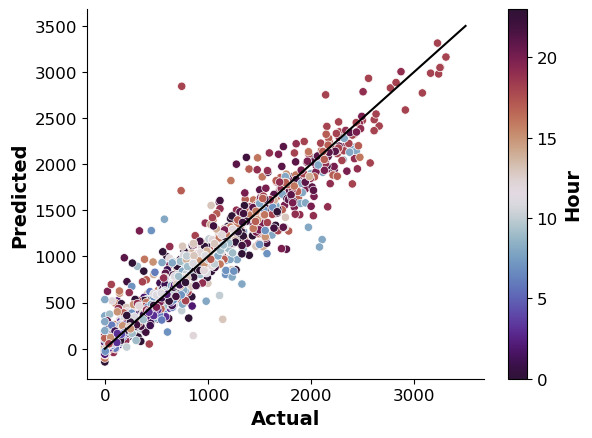

In [90]:
pred_test = trained_model_xgboost.predict(x_test_xgb)

hue_var = x_test_xgb[:,0]
colormap = 'twilight_shifted'
# plt.rc('xtick',labelsize=12)
# plt.rc('ytick',labelsize=12)

ax = sns.scatterplot(x=y_test_xgb, y=pred_test, hue = hue_var,
               palette= colormap)

#plot 1:1 line
x = np.arange(0,3500)
ax.plot(x, x, color = 'k')

norm = plt.Normalize(hue_var.min(), hue_var.max())
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])

cbar = ax.figure.colorbar(sm, ax=ax)
cbar.set_label('Hour', fontweight = 'bold', fontsize = 14)
ax.get_legend().remove()

ax.set_ylabel('Predicted', fontweight = 'bold', fontsize = 14)
ax.set_xlabel('Actual', fontweight = 'bold', fontsize = 14)

ax.spines[['right', 'top']].set_visible(False)

plt.savefig('scatter_test_set_hour_in_color.png', 
            format = 'png', dpi = 250, bbox_inches = 'tight',
        facecolor = 'white')

In [74]:
df_x_test_xgb = pd.DataFrame(data = x_test_xgb, columns=features.columns)

error = pred_test - y_test_xgb

indx_max = np.argmax(error)

df_x_test_xgb.iloc[indx_max]

Hour                           18
Temperature(°C)              29.2
Humidity(%)                    35
Wind speed (m/s)              2.7
Visibility (10m)             1900
Dew point temperature(°C)    12.1
Solar Radiation (MJ/m2)      1.27
Rainfall(mm)                  0.0
Snowfall (cm)                 0.0
Seasons                         2
Holiday                         0
Functioning Day                 1
weekday                         0
Name: 1412, dtype: object

In [80]:
from scipy.stats import linregress

res = linregress(pred_test, y_test_xgb)

res.rvalue**2

np.float64(0.9330061943550092)

In [84]:
df[df['Rented Bike Count'] > 25]['Rented Bike Count'].mean()

np.float64(744.2200241254524)